# The Project Task

- import/download CIFAR10 dataset
- create train/dev/test DataLoaders
- make sure the data are 3x32x32
- categorize with CNN, but don't stress about accuracy
- show plots for train/test loss/accuracy over epochs
- show dev set loss/accuracy as the very last epoch sample

# Implementation

In [33]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader,TensorDataset,Subset

# for getting summary info on models
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [34]:
# use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [35]:
transform = transforms.Compose([ transforms.ToTensor(),
                                 transforms.Normalize([.5,.5,.5],[.5,.5,.5]),
                              ])

# Import CIFA10 dataset
root_dir = '../sample_data/cifar10'
cifar10_train = datasets.CIFAR10(root=root_dir, train=True,  download=True, transform=transform)
cifar10_test  = datasets.CIFAR10(root=root_dir, train=False, download=True, transform=transform)

# split the devtest into two separate sets
print('cifar10_train.data.shape =', cifar10_train.data.shape)
print('cifar10_test.data.shape =', cifar10_test.data.shape)
print('cifar10_train.targets.shape =', len(cifar10_train.targets))
print('cifar10_test.targets.shape =', len(cifar10_test.targets))

# Create labels to names mapping:
labels2names = dict(zip(sorted(set(cifar10_train.targets)), cifar10_train.classes))
print('labels2names: ', labels2names)

cifar10_train.data.shape = (50000, 32, 32, 3)
cifar10_test.data.shape = (10000, 32, 32, 3)
cifar10_train.targets.shape = 50000
cifar10_test.targets.shape = 10000
labels2names:  {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}


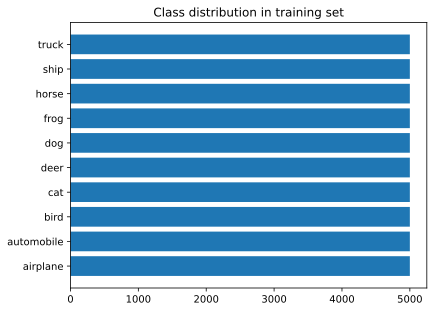

In [36]:
# Show classe/counts statistics
unique, counts = np.unique(cifar10_train.targets, return_counts=True)
class_counts = dict(zip(unique, counts))

plt.figure()
plt.barh([labels2names[i] for i in unique], counts)
plt.title('Class distribution in training set')
plt.show()

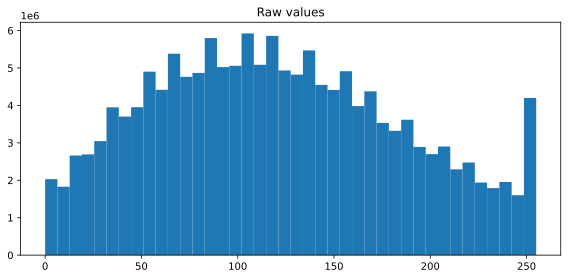

In [37]:
# Show histogram of normalized data for each plane/channel
fig, axs = plt.subplots(1,1, figsize=(8,4))
axs.hist(cifar10_train.data[:,:,:,:].flatten(), 40)
axs.set_title('Raw values')

fig.tight_layout()
plt.show()

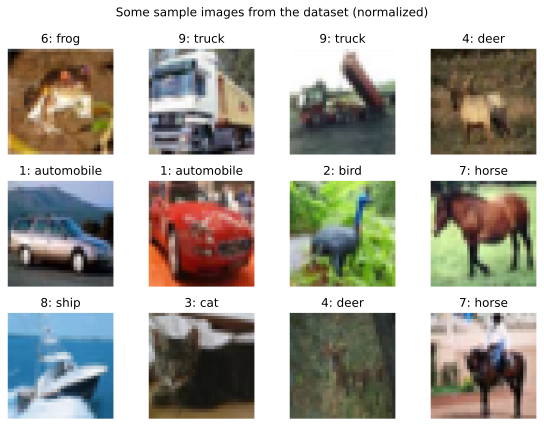

In [38]:
# Show some sample images
fig = plt.figure(figsize=(8,6))
for i in range(12):
    ax = fig.add_subplot(3,4,i+1)
    ax.imshow(cifar10_train.data[i].reshape(32, 32, 3))  # transpose to HWC for display
    ax.set_title(f'{cifar10_train.targets[i]}: {labels2names[cifar10_train.targets[i]]}')
    ax.axis('off')
fig.suptitle('Some sample images from the dataset (normalized)')
fig.tight_layout()
plt.show()

# Split into train/test/dev sets

In [39]:
randidx = np.random.permutation(10000)   # a random permutation of indices
devset  = Subset(cifar10_test,randidx[:6000]) # Subset for devset
testset = Subset(cifar10_test,randidx[6000:]) # Subset for test

# transform to dataloaders
batchsize    = 100
train_loader = DataLoader(cifar10_train,batch_size=batchsize,shuffle=True,drop_last=True)
dev_loader   = DataLoader(devset,  batch_size=len(devset)) # note: devtest in batches!
test_loader  = DataLoader(testset, batch_size=len(testset))

In [40]:
# check size (should be images X channels X width X height
print( train_loader.dataset.data.shape )
print( len(train_loader.dataset.targets) )

print( test_loader.dataset.dataset.data.shape )
print( len(test_loader.dataset.dataset.targets) )

print( dev_loader.dataset.dataset.data.shape )
print( len(dev_loader.dataset.dataset.targets) )

print('\nData value range:')
print('train_loader: ', train_loader.dataset.data.min(), train_loader.dataset.data.max() )
print('test_loader: ', test_loader.dataset.dataset.data.min(), test_loader.dataset.dataset.data.max() )
print('test_loader: ', test_loader.dataset.dataset.data.min(), test_loader.dataset.dataset.data.max() )
print('dev_loader: ', dev_loader.dataset.dataset.data.min(), dev_loader.dataset.dataset.data.max() )

(50000, 32, 32, 3)
50000
(10000, 32, 32, 3)
10000
(10000, 32, 32, 3)
10000

Data value range:
train_loader:  0 255
test_loader:  0 255
test_loader:  0 255
dev_loader:  0 255


# Create CNN Model

In [61]:
def makeTheNet(lr:float=.001, printtoggle=False):
    class cifar10net(nn.Module):
        def __init__(self,printtoggle):
            super().__init__()
            
            # torch.manual_seed(1)
            self.print = printtoggle
            
            # For equation see: https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
            CNNLayerOutSize = lambda in_dim, conv, pooling: \
                int(np.ceil((in_dim + 2*conv.padding[0] - conv.kernel_size[0])//conv.stride[0] + 1)//pooling)
                
            self.inSize = 32
            self.p2d_ksz = 2  # kernel size for maxpool2d
            self.p2d_strd = 2 # stride for maxpool2d
            self.p_drop = .2
        
            # Conv Layers:
            self.conv1  = nn.Conv2d(3,32,3, padding=1)
            self.bn1 = nn.BatchNorm2d(self.conv1.out_channels)
            nOutCNNLayer1 = CNNLayerOutSize(self.inSize, self.conv1, self.p2d_ksz)
            if self.print: print(f'nOutCNNLayer1: {nOutCNNLayer1}')
            
            self.conv2 = nn.Conv2d(self.conv1.out_channels,128,3, padding=0)
            self.bn2 = nn.BatchNorm2d(self.conv2.out_channels)
            nOutCNNLayer2 = CNNLayerOutSize(nOutCNNLayer1, self.conv2, self.p2d_ksz)
            if self.print: print(f'nOutCNNLayer2: {nOutCNNLayer2}')
            
            self.conv3 = nn.Conv2d(self.conv2.out_channels,256,3, padding=0)
            self.bn3 = nn.BatchNorm2d(self.conv3.out_channels)
            nOutCNNLayer3 = CNNLayerOutSize(nOutCNNLayer2, self.conv3, self.p2d_ksz)
            if self.print: print(f'nOutCNNLayer3: {nOutCNNLayer3}')
            
            # Flat Layers:
            self.fc1 = nn.Linear(nOutCNNLayer3*nOutCNNLayer3*self.conv3.out_channels, 512)
            self.bn_fc1 = nn.BatchNorm1d(self.fc1.out_features)
            
            self.fc2 = nn.Linear(self.fc1.out_features, 64)
            self.bn_fc2 = nn.BatchNorm1d(self.fc2.out_features)
            
            self.fc3 = nn.Linear(self.fc2.out_features, 10)
            self.bn_fc3 = nn.BatchNorm1d(self.fc3.out_features)
            
            # apply custom init to all submodules
            # self.apply(self._init_weights)
            
        def _init_weights(self, m):
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            # add other layer types if needed
            elif isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')

        def forward(self, x):
            if self.print: print(f'Input: {list(x.shape)}')
            
            # Conv Layers:
            x = self.conv1(x)
            x = F.max_pool2d(x, kernel_size=self.p2d_ksz)
            x = F.relu(x)
            x = self.bn1(x)
            x = F.dropout2d(x, p=self.p_drop, training=self.training)
            if self.print: print(f'First CPBR block: {list(x.shape)}')
            
            x = self.conv2(x)
            x = F.max_pool2d(x, kernel_size=self.p2d_ksz)
            x = F.relu(x)
            x = self.bn2(x)
            x = F.dropout2d(x, p=self.p_drop, training=self.training)
            if self.print: print(f'Second CPR block: {list(x.shape)}')
            
            x = self.conv3(x)
            x = F.max_pool2d(x, kernel_size=self.p2d_ksz)
            x = F.relu(x)
            x = self.bn3(x)
            x = F.dropout2d(x, p=self.p_drop, training=self.training)
            if self.print: print(f'Third CPR block: {list(x.shape)}')

            # Flat Layers:
            x = x.flatten(start_dim=1)
            if self.print: print(f'Vectorized: {list(x.shape)}')
            
            x = self.fc1(x)
            x = F.relu(x)
            x = self.bn_fc1(x)
            x = F.dropout(x, p=self.p_drop, training=self.training)
        
            x = self.fc2(x)
            x = self.bn_fc2(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.p_drop, training=self.training)
            
            x = self.fc3(x)
            # x = self.bn_fc3(x)
            # x = F.softmax(x, dim=1)
            x = F.log_softmax(x, dim=1)
            if self.print: print(f'Final output: {list(x.shape)}')
            
            return x
        
        @staticmethod
        def accuracy(yHat, y):
            return torch.mean((torch.argmax(yHat, axis=1) == y).float()).item()
        
    net = cifar10net(printtoggle=printtoggle)
    lossfun = nn.NLLLoss()
    # lossfun = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(),lr=lr,weight_decay=1e-5)
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.01, patience=3, min_lr=.0001)
    
    return net,lossfun,optimizer,lr_scheduler

# test the model with one batch
net,lossfun,optimizer,_ = makeTheNet(printtoggle=True)
X,y = next(iter(train_loader))
yHat = net(X)

# check size of output
print(f'\nOutput size: {yHat.shape}')

# # now let's compute the loss and accuracy
loss = lossfun(yHat, y)
acc = net.accuracy(yHat, y)
print(f'Accuracy: {acc}')
print(f'Loss: {loss}')

net_summary,_,_,_ = makeTheNet() 
summary(net_summary,(3,32,32), device='cpu')

nOutCNNLayer1: 16
nOutCNNLayer2: 7
nOutCNNLayer3: 2
Input: [100, 3, 32, 32]
First CPBR block: [100, 32, 16, 16]
Second CPR block: [100, 128, 7, 7]
Third CPR block: [100, 256, 2, 2]
Vectorized: [100, 1024]
Final output: [100, 10]

Output size: torch.Size([100, 10])
Accuracy: 0.10000000149011612
Loss: 2.4537134170532227
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 16, 16]              64
            Conv2d-3          [-1, 128, 14, 14]          36,992
       BatchNorm2d-4            [-1, 128, 7, 7]             256
            Conv2d-5            [-1, 256, 5, 5]         295,168
       BatchNorm2d-6            [-1, 256, 2, 2]             512
            Linear-7                  [-1, 512]         524,800
       BatchNorm1d-8                  [-1, 512]           1,024
            Linear-9                   

# Create a function to train the model

In [62]:
# a function that trains the model
def function2trainTheModel(train_loader, dev_loader, lr, numepochs:int=3):

  # create a new model
  net,lossfun,optimizer,lr_scheduler = makeTheNet(lr=lr)

  # send the model to the GPU
  net.to(device)

  # initialize losses
  trainLoss = torch.zeros(numepochs)
  devLoss  = torch.zeros(numepochs)
  trainAcc  = torch.zeros(numepochs)
  devAcc   = torch.zeros(numepochs)

  # loop over epochs
  for epochi in range(numepochs):
    net.train()

    # loop over training data batches
    batchLoss = []
    batchAcc  = []
    
    for batchi,(X,y) in enumerate(train_loader):

      # push data to GPU
      X = X.to(device)
      y = y.to(device)

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss and error from this batch
      batchLoss.append(loss.item())
      batchAcc.append(net.accuracy(yHat,y))
    # end of batch loop...

    # and get average losses and error rates across the batches
    trainLoss[epochi] = np.mean(batchLoss)
    trainAcc[epochi]  = 100*np.mean(batchAcc)

    ### dev performance
    net.eval()
    X,y = next(iter(dev_loader))
    X = X.to(device)
    y = y.to(device)
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)
      loss = lossfun(yHat,y)
    devLoss[epochi] = loss.item()
    devAcc[epochi] = 100*net.accuracy(yHat,y)
    
    lr_scheduler.step(devLoss[epochi])  # step the LR scheduler ater test/dev loss computation

    print(f'epoch {epochi+1}/{numepochs}: '
          f'train loss: {trainLoss[epochi]:.4f} '
          f'dev loss: {devLoss[epochi]:.4f} '
          f'train acc: {trainAcc[epochi]:.2f}% '
          f'dev acc: {devAcc[epochi]:.2f}%', end='\r' )

  # end epochs
  
  net.eval() # set model to eval mode as done training

  # function output
  return trainLoss,devLoss,trainAcc,devAcc,net

# Train the model, show results

In [63]:
trainLoss,devLoss,trainAcc,devAcc,net = function2trainTheModel(train_loader, dev_loader, lr=.001, numepochs=25)

In [64]:
# Run on test_set
X_test,y_test = next(iter(test_loader))
X_test = X_test.to(device)
y_test = y_test.to(device)

with torch.no_grad():
    yHat_test = net(X_test).cpu().detach()
X_test = X_test.cpu().detach().to(torch.float32)
y_test = y_test.cpu().detach()

testLoss = lossfun(yHat_test,y_test).item()
testAcc  = 100*net.accuracy(yHat_test,y_test)

print('testLoss:', testLoss)
print('testAcc:', testAcc)

testLoss: 0.6347144246101379
testAcc: 80.52499890327454


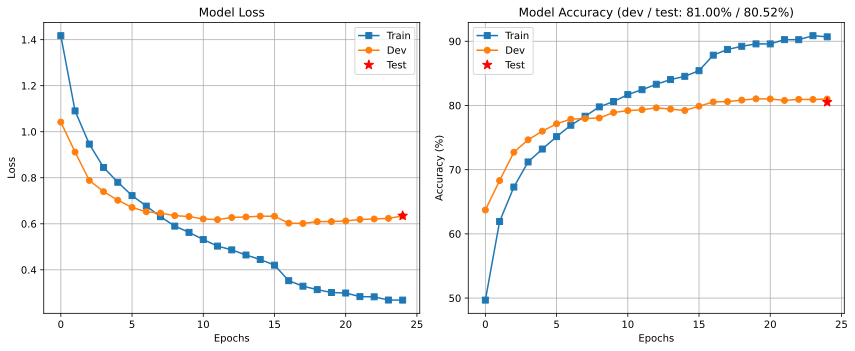

In [65]:
fig,axs = plt.subplots(1,2,figsize=(12,5))

axs[0].plot(trainLoss,'s-',label='Train')
axs[0].plot(devLoss,'o-',label='Dev')
axs[0].plot(len(trainLoss)-1, testLoss,'r*',markersize=10, label='Test')
axs[0].set_ylabel('Loss')
axs[0].set_title(f'Model Loss')

axs[1].plot(trainAcc,'s-',label='Train')
axs[1].plot(devAcc,'o-',label='Dev')
axs[1].plot(len(trainAcc)-1, testAcc,'r*',markersize=10, label='Test')
axs[1].set_ylabel('Accuracy (%)')
axs[1].set_title(f'Model Accuracy (dev / test: {devAcc[-1]:.2f}% / {testAcc:.2f}%)')

for a in axs.flatten():
    a.grid(True)
    a.legend()
    a.set_xlabel('Epochs')

fig.tight_layout()
plt.show()

# Show predicted Test images and their Labels

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.96862745..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90588236..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8901961..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92156863..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.9607843].
Clippi

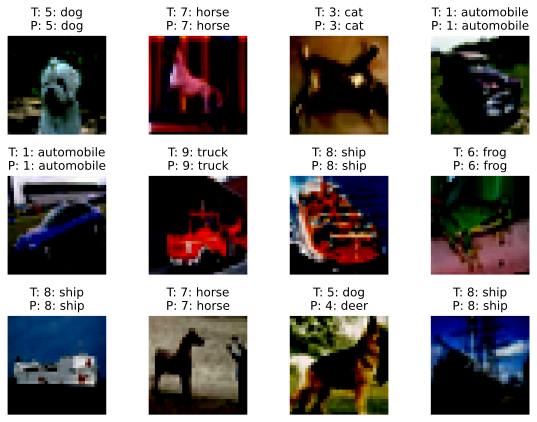

In [66]:
# Show some sample images
fig = plt.figure(figsize=(8,6))

random_indexes = np.random.choice(X_test.shape[0], 12, replace=False)
for idx, i in enumerate(random_indexes):
    ax = fig.add_subplot(3,4,idx+1)
    ax.imshow(X_test[i].cpu().numpy().transpose(1, 2, 0))  # transpose to HWC for display
    ax.set_title(f'T: {y_test[i].item()}: {labels2names[y_test[i].item()]}\nP: {torch.argmax(yHat_test[i]).item()}: {labels2names[torch.argmax(yHat_test[i]).item()]}')
    ax.axis('off')
fig.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

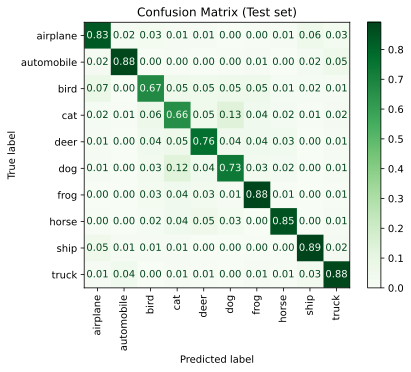

In [67]:
# Show confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig = plt.figure(figsize=(10,10))
cm_display = ConfusionMatrixDisplay.from_predictions(y_test.cpu().numpy(), torch.argmax(yHat_test,axis=1).cpu().numpy(),
                                                    display_labels=[labels2names[i] for i in range(10)],
                                                    cmap=plt.cm.Greens,
                                                    xticks_rotation='vertical',
                                                    values_format='.2f',
                                                    normalize='true')
cm_display.ax_.set_title('Confusion Matrix (Test set)')

fig.tight_layout()
plt.show()